# Chapter 2: Data Quality and Feature Engineering

This notebook covers:
- **§2.2** Data Generation (creating synthetic credit data)
- **§2.3** Data Cleaning (validation, deduplication, standardization)
- **§2.4** Feature Engineering
- **§2.5** Train/Validation/Test Split

> **Output:** `model_data/train.csv`, `model_data/val.csv`, `model_data/test.csv`
> These files are used by the Chapter 3 and Chapter 4 notebooks.

## 2.2 Data Generation

In [1]:
from generate_credit_data import CreditDataGenerator

# Create generator
generator = CreditDataGenerator(
    n_accounts=5000, #you can increase this number to get more accurate statistics
    seed=123,
    start_date='2019-01-01',
    prediction_date='2024-01-01',
    default_rate=0.05
)

# Generate all data (takes 20-30 seconds)
data = generator.generate_all(output_dir='synthetic_credit_data')


Credit Data Generator - Starting

Configuration:
  Accounts: 5,000
  Seed: 123
  Date range: 2019-01-01 to 2024-01-01
  Target default rate: 5.0%

Step 1: Generating accounts with credit attributes...
Generating 5000 accounts...
  Adding credit bureau attributes...
  Adding application data...
  Adding demographic proxies...
  Generating default labels...
    Generated 251 defaults (5.0% default rate)
    Default rate by region:
      Region A: 3.6%
      Region B: 5.4%
      Region C: 7.1% ⚠️

Step 2: Generating transaction history...
Generating transactions...

Step 3: Generating balance snapshots...
Generating balance snapshots...

Step 4: Injecting realistic data quality issues...
Injecting data quality issues...

Step 5: Saving data to synthetic_credit_data/...

✅ Credit Data Generation Complete!

📂 Output directory: synthetic_credit_data/

📊 Data Summary:
   Accounts:     5,000
   Transactions: 45,584
   Balances:     153,503
   Default rate: 5.0%

📁 File Structure:
   synthetic

In [2]:
import pandas as pd

# Load the messy data
accounts = pd.read_csv('synthetic_credit_data/raw/accounts.csv')
print(f"✅ Generated {len(accounts):,} accounts")
print(f"✅ Default rate: {accounts['defaulted'].mean():.1%}")

✅ Generated 5,100 accounts
✅ Default rate: 5.0%


## 2.3 Data Quality Assessment

In [3]:
print("📊 Data Quality Report:")
print(f"\nTotal accounts: {len(accounts)}")

# Missing FICO scores
missing_fico = accounts['fico_score'].isna().sum()
print(f"\n1. Missing FICO scores: {missing_fico} ({missing_fico/len(accounts)*100:.1f}%)")

# Out-of-range FICO scores
invalid_fico = ((accounts['fico_score'] < 300) | (accounts['fico_score'] > 850)).sum()
print(f"2. Invalid FICO scores (out of 300-850 range): {invalid_fico}")

if invalid_fico > 0:
    invalid_scores = accounts[(accounts['fico_score'] < 300) | (accounts['fico_score'] > 850)]['fico_score'].value_counts()
    print(f"   Specific invalid values: {dict(invalid_scores)}")

# Duplicates
duplicates = accounts['account_id'].duplicated().sum()
print(f"3. Duplicate account IDs: {duplicates} ({duplicates/len(accounts)*100:.1f}%)")

print(f"\n⚠️ These issues will distort analysis if not addressed!")
print(f"Total problematic records: {missing_fico + invalid_fico + duplicates}")

📊 Data Quality Report:

Total accounts: 5100

1. Missing FICO scores: 224 (4.4%)
2. Invalid FICO scores (out of 300-850 range): 44
   Specific invalid values: {250.0: np.int64(44)}
3. Duplicate account IDs: 100 (2.0%)

⚠️ These issues will distort analysis if not addressed!
Total problematic records: 368


### Visualizing Data Quality Issues

Before we clean, let's visualize what we found. Figure 2.1 summarizes the three categories of data quality problems in our raw dataset: missing values, duplicate records, and inconsistent date formatting.

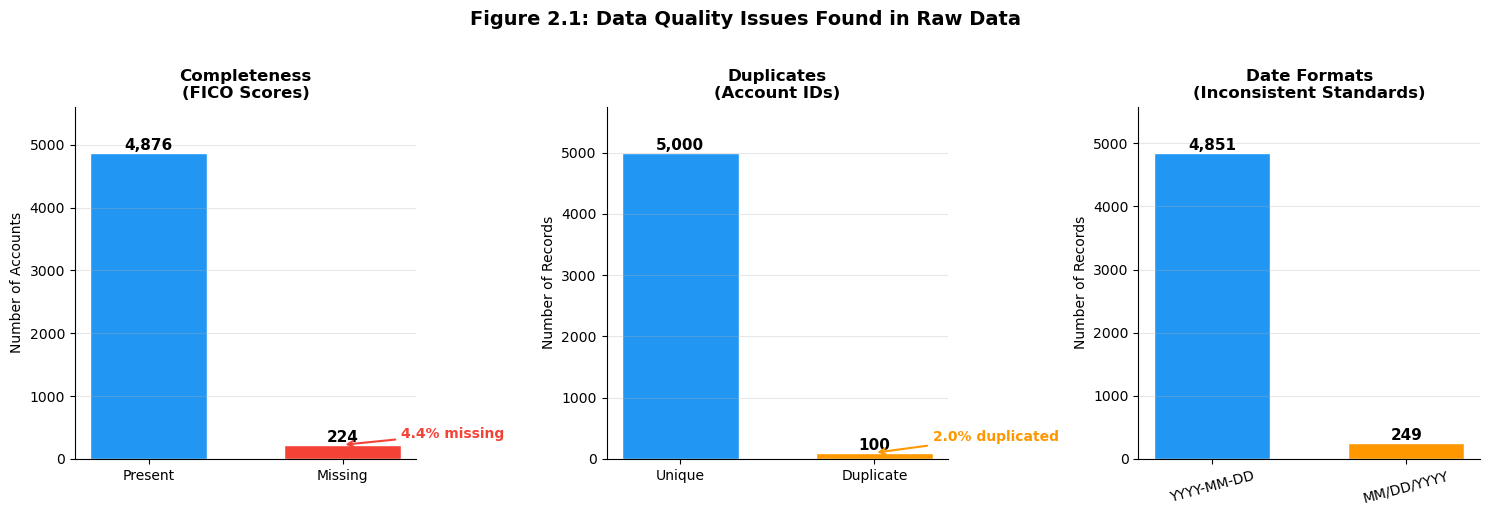


📊 Summary: 324 problematic records identified across 5,100 total


In [4]:
# Figure 2.1: Data Quality Issues
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 2.1: Data Quality Issues Found in Raw Data', 
             fontsize=14, fontweight='bold', y=1.02)

# --- Panel 1: Completeness ---
missing_fico = accounts['fico_score'].isna().sum()
valid_fico = accounts['fico_score'].notna().sum()
ax1 = axes[0]
bars1 = ax1.bar(['Present', 'Missing'], [valid_fico, missing_fico],
                color=['#2196F3', '#F44336'], edgecolor='white', width=0.6)
ax1.bar_label(bars1, fmt='{:,.0f}', fontsize=11, fontweight='bold')
ax1.set_title('Completeness\n(FICO Scores)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Accounts')
ax1.set_ylim(0, max(valid_fico, missing_fico) * 1.15)
# Add percentage annotation
pct_missing = missing_fico / len(accounts) * 100
ax1.annotate(f'{pct_missing:.1f}% missing',
             xy=(1, missing_fico), xytext=(1.3, missing_fico * 1.5),
             fontsize=10, color='#F44336', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#F44336', lw=1.5))

# --- Panel 2: Duplicates ---
duplicates = accounts['account_id'].duplicated().sum()
unique = len(accounts) - duplicates
ax2 = axes[1]
bars2 = ax2.bar(['Unique', 'Duplicate'], [unique, duplicates],
                color=['#2196F3', '#FF9800'], edgecolor='white', width=0.6)
ax2.bar_label(bars2, fmt='{:,.0f}', fontsize=11, fontweight='bold')
ax2.set_title('Duplicates\n(Account IDs)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Records')
ax2.set_ylim(0, max(unique, duplicates) * 1.15)
pct_dup = duplicates / len(accounts) * 100
ax2.annotate(f'{pct_dup:.1f}% duplicated',
             xy=(1, duplicates), xytext=(1.3, duplicates * 3),
             fontsize=10, color='#FF9800', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#FF9800', lw=1.5))

# --- Panel 3: Date Format Inconsistencies ---
# Check how many dates match each format pattern
import re
dates = accounts['open_date'].astype(str)
iso_pattern = r'^\d{4}-\d{2}-\d{2}'  # YYYY-MM-DD
us_pattern = r'^\d{1,2}/\d{1,2}/\d{4}'  # MM/DD/YYYY
iso_count = dates.str.match(iso_pattern).sum()
us_count = dates.str.match(us_pattern).sum()
other_count = len(dates) - iso_count - us_count
ax3 = axes[2]
labels = ['YYYY-MM-DD', 'MM/DD/YYYY']
counts = [iso_count, us_count]
colors = ['#2196F3', '#FF9800']
if other_count > 0:
    labels.append('Other')
    counts.append(other_count)
    colors.append('#F44336')
bars3 = ax3.bar(labels, counts, color=colors, edgecolor='white', width=0.6)
ax3.bar_label(bars3, fmt='{:,.0f}', fontsize=11, fontweight='bold')
ax3.set_title('Date Formats\n(Inconsistent Standards)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Records')
ax3.set_ylim(0, max(counts) * 1.15)
ax3.tick_params(axis='x', rotation=15)

# Style all panels
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig_2_1_data_quality_issues.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"\n📊 Summary: {missing_fico + duplicates} problematic records identified across {len(accounts):,} total")

## 2.3.1 Cleaning: Invalid Records and Duplicates

In [5]:
# Load raw data
accounts_raw = pd.read_csv('synthetic_credit_data/raw/accounts.csv')

print(f"Original: {len(accounts_raw)} accounts")

# Remove invalid and missing FICO scores
accounts_clean = accounts_raw[
    (accounts_raw['fico_score'].notna()) &      # Remove missing
    (accounts_raw['fico_score'] >= 300) &       # Remove too low
    (accounts_raw['fico_score'] <= 850)         # Remove too high
].copy()

# Remove duplicates
accounts_clean = accounts_clean.drop_duplicates(subset='account_id', keep='first')

print(f"After cleaning: {len(accounts_clean)} accounts")
print(f"Removed: {len(accounts_raw) - len(accounts_clean)} accounts\n")

# Verify the cleaning worked
print("✓ Validation checks:")
print(f"  No missing FICO: {accounts_clean['fico_score'].isna().sum() == 0}")
print(f"  All FICO in range: {((accounts_clean['fico_score'] >= 300) & (accounts_clean['fico_score'] <= 850)).all()}")
print(f"  No duplicate IDs: {accounts_clean['account_id'].duplicated().sum() == 0}")

Original: 5100 accounts
After cleaning: 4739 accounts
Removed: 361 accounts

✓ Validation checks:
  No missing FICO: True
  All FICO in range: True
  No duplicate IDs: True


## 2.3.2 Standardizing Date Formats

In [6]:
# Standardize date formats (fix MM/DD/YYYY → YYYY-MM-DD inconsistencies)
print("\n📅 Standardizing date formats...")
accounts_clean['open_date'] = pd.to_datetime(accounts_clean['open_date'], format='mixed')
if 'default_date' in accounts_clean.columns:
    accounts_clean['default_date'] = pd.to_datetime(accounts_clean['default_date'], format='mixed', errors='coerce')
print("   ✓ All dates converted to standard format")


📅 Standardizing date formats...
   ✓ All dates converted to standard format


## 2.3.3 Cleaning Transactions and Balances

Remove records linked to accounts we dropped, and standardize dates across all tables.

In [7]:
# Clean transactions (remove those from problematic accounts)
transactions_raw = pd.read_csv('synthetic_credit_data/raw/transactions.csv')
transactions_clean = transactions_raw[
    transactions_raw['account_id'].isin(accounts_clean['account_id'])
].copy()

# Standardize transaction dates
transactions_clean['transaction_date'] = pd.to_datetime(transactions_clean['transaction_date'], format='mixed')

# Clean balances (remove those from problematic accounts)
balances_raw = pd.read_csv('synthetic_credit_data/raw/balances.csv')
balances_clean = balances_raw[
    balances_raw['account_id'].isin(accounts_clean['account_id'])
].copy()

# Standardize balance dates
balances_clean['balance_date'] = pd.to_datetime(balances_clean['balance_date'], format='mixed')


# Save all three cleaned files for use in Part 2
print("\n💾 Saving cleaned data...")
accounts_clean.to_csv('synthetic_credit_data/clean/accounts_clean.csv', index=False)
transactions_clean.to_csv('synthetic_credit_data/clean/transactions_clean.csv', index=False)
balances_clean.to_csv('synthetic_credit_data/clean/balances_clean.csv', index=False)

print(f"✅ Cleaned data saved:")
print(f"   Accounts:     {len(accounts_clean):,} records")
print(f"   Transactions: {len(transactions_clean):,} records")
print(f"   Balances:     {len(balances_clean):,} records")
print(f"\n💡 These files will be used for feature engineering in Part 2.")


💾 Saving cleaned data...
✅ Cleaned data saved:
   Accounts:     4,739 records
   Transactions: 43,169 records
   Balances:     145,708 records

💡 These files will be used for feature engineering in Part 2.


## 2.3.4 Post-Cleaning Validation

In [8]:
# Check default distribution
print(f"\n📊 Default Statistics:")
print(f"Overall default rate: {accounts_clean['defaulted'].mean():.1%}")

print(f"\nDefault rate by region:")
region_stats = accounts_clean.groupby('region')['defaulted'].agg(['mean', 'count'])
region_stats['mean'] = region_stats['mean'].map('{:.1%}'.format)
print(region_stats)

print(f"\nDefault rate by FICO band:")
accounts_clean['fico_band'] = pd.cut(
    accounts_clean['fico_score'], 
    bins=[0, 580, 670, 740, 850],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)
fico_stats = accounts_clean.groupby('fico_band', observed=False)['defaulted'].agg(['mean', 'count'])
fico_stats['mean'] = fico_stats['mean'].map('{:.1%}'.format)
print(fico_stats)


📊 Default Statistics:
Overall default rate: 5.0%

Default rate by region:
        mean  count
region             
A       3.5%   1907
B       5.5%   1879
C       7.1%    953

Default rate by FICO band:
            mean  count
fico_band              
Poor       10.2%    402
Fair        6.0%   1564
Good        5.3%   1576
Excellent   1.7%   1197


## 2.4 Feature Engineering

We use the `CreditFeatureEngineer` class (see `engineer_credit_features.py`) to create
transaction-based, balance-based, and account-level features.

In [14]:
# Step 1: Load cleaned data (after running your cleaning pipeline)
import pandas as pd
from engineer_credit_features import CreditFeatureEngineer

print("Loading cleaned data...")
accounts = pd.read_csv('synthetic_credit_data/clean/accounts_clean.csv')
transactions = pd.read_csv('synthetic_credit_data/clean/transactions_clean.csv')
balances = pd.read_csv('synthetic_credit_data/clean/balances_clean.csv')

# Step 2: Engineer features
print("\nEngineering features...")
engineer = CreditFeatureEngineer(prediction_date='2024-01-01')
accounts_enriched = engineer.engineer_all_features(accounts, transactions, balances)

# Step 3: Inspect results
print(f"\nOriginal features: {len([c for c in accounts.columns if not c.startswith('feat_')])}")
print(f"Engineered features: {len(engineer.get_feature_list(accounts_enriched))}")
print(f"Total features: {len(accounts_enriched.columns)}")

Loading cleaned data...

Engineering features...
Engineering features from transaction and balance history...
Prediction date: 2024-01-01
Accounts: 4,739
Transactions: 43,169
Balances: 145,708

  transaction_date: Filtered 0 future records
  balance_date: Filtered 0 future records
After point-in-time filter:
Transactions: 43,169
Balances: 145,708

Engineering balance features...
  Added 8 balance features
Engineering transaction features...
  Added 18 transaction features
Engineering spending pattern features...
  Added spending pattern features
Engineering temporal features...
  Added 11 temporal features

Feature engineering complete!
Total features: 68
New features added: 24

Original features: 24
Engineered features: 44
Total features: 68


In [10]:
# Step 4: Preview feature distributions
feature_stats = accounts_enriched[engineer.get_feature_list(accounts_enriched)].describe()
print("\nFeature statistics:")
print(feature_stats.T[['mean', 'std', 'min', 'max']])

# Step 5: Check for correlation with target
correlation_with_default = accounts_enriched[
    engineer.get_feature_list(accounts_enriched) + ['defaulted']
].corr()['defaulted'].sort_values(ascending=False)

print("\nTop features correlated with default:")
print(correlation_with_default.head(10))

print("\nFeatures negatively correlated with default (protective):")
print(correlation_with_default.tail(10))



Feature statistics:
                                       mean          std           min  \
feat_avg_balance                 803.594254  9404.167161 -41770.623333   
feat_balance_std                 978.041409   531.924725      0.000000   
feat_min_balance                -888.249692  9432.442927 -45229.300000   
feat_max_balance                2557.123988  9446.124568 -40261.220000   
feat_avg_ledger_balance          828.529038  9404.343454 -41747.158431   
feat_total_overdrafts              3.704579    13.101887      0.000000   
feat_avg_monthly_overdrafts        0.102208     0.343409      0.000000   
feat_balance_trend               110.995604  1530.922309  -6262.074848   
feat_num_transactions              9.109306     3.787501      0.000000   
feat_avg_transaction_amount       -7.921736   104.440768  -1416.310000   
feat_transaction_amount_std      160.825438   237.198500      0.000000   
feat_total_transaction_volume    -76.264423   852.668815  -8497.860000   
feat_num_debits  

In [11]:
# Step 6: Save everything
accounts_enriched.to_csv('synthetic_credit_data/accounts_final_features.csv', index=False)
engineer.logger.save_report('synthetic_credit_data/feature_engineering_log.csv')
engineer.save_feature_documentation(accounts_enriched, 'synthetic_credit_data/feature_dictionary.csv')

print("\n✅ Feature engineering complete!")
print("📂 Outputs saved to:")
print("   - synthetic_credit_data/accounts_final_features.csv")
print("   - synthetic_credit_data/feature_engineering_log.csv")
print("   - synthetic_credit_data/feature_dictionary.csv")

Feature engineering report saved to synthetic_credit_data/feature_engineering_log.csv

Feature documentation saved to synthetic_credit_data/feature_dictionary.csv

✅ Feature engineering complete!
📂 Outputs saved to:
   - synthetic_credit_data/accounts_final_features.csv
   - synthetic_credit_data/feature_engineering_log.csv
   - synthetic_credit_data/feature_dictionary.csv


## 2.5 Temporal Train/Validation/Test Split

We split by account open date to simulate real-world deployment:
- **Train:** oldest accounts
- **Validation:** middle period (for tuning)
- **Test:** most recent accounts (held out until final evaluation)

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


def temporal_train_test_split(accounts, prediction_date='2024-01-01', 
                                val_months=6, test_months=6):
    """
    Split data temporally for credit modeling.
    
    Structure:
    - Train: All accounts opened before (prediction_date - test_months - val_months)
    - Validation: Accounts opened in (prediction_date - test_months - val_months) to (prediction_date - test_months)
    - Test: Accounts opened in (prediction_date - test_months) to prediction_date
    
    Args:
        accounts: DataFrame with 'open_date' and features
        prediction_date: Date at which we make predictions
        val_months: Months of data for validation set
        test_months: Months of data for test set
        
    Returns:
        train_df, val_df, test_df
    """
    prediction_date = pd.to_datetime(prediction_date)
    
    # Make a copy to avoid modifying original
    accounts = accounts.copy()
    
    # Parse dates with mixed formats (handles YYYY-MM-DD and MM/DD/YYYY)
    accounts['open_date'] = pd.to_datetime(accounts['open_date'], format='mixed')
    
    # Define cutoff dates
    test_cutoff = prediction_date - pd.DateOffset(months=test_months)
    val_cutoff = test_cutoff - pd.DateOffset(months=val_months)
    
    # Split
    train = accounts[accounts['open_date'] < val_cutoff].copy()
    val = accounts[
        (accounts['open_date'] >= val_cutoff) & (accounts['open_date'] < test_cutoff)
    ].copy()
    test = accounts[accounts['open_date'] >= test_cutoff].copy()
    
    print(f"Temporal Split:")
    print(f"  Train: {len(train)} accounts ({train['defaulted'].mean():.1%} default rate)")
    print(f"  Val:   {len(val)} accounts ({val['defaulted'].mean():.1%} default rate)")
    print(f"  Test:  {len(test)} accounts ({test['defaulted'].mean():.1%} default rate)")
    print(f"\n  Train date range: {train['open_date'].min().date()} to {train['open_date'].max().date()}")
    print(f"  Val date range:   {val['open_date'].min().date()} to {val['open_date'].max().date()}")
    print(f"  Test date range:  {test['open_date'].min().date()} to {test['open_date'].max().date()}")
    
    return train, val, test


In [13]:
import os

# Usage
accounts = pd.read_csv('synthetic_credit_data/accounts_final_features.csv')

train_df, val_df, test_df = temporal_train_test_split(
    accounts,
    prediction_date='2024-01-01',
    val_months=6,
    test_months=6
)

# Create directory if it doesn't exist
os.makedirs('model_data', exist_ok=True)

# Save splits (for reproducibility)
train_df.to_csv('model_data/train.csv', index=False)
val_df.to_csv('model_data/val.csv', index=False)
test_df.to_csv('model_data/test.csv', index=False)

print("\n✅ Train/val/test splits saved to model_data/")

Temporal Split:
  Train: 3799 accounts (5.1% default rate)
  Val:   477 accounts (3.4% default rate)
  Test:  463 accounts (6.5% default rate)

  Train date range: 2019-01-01 to 2022-12-31
  Val date range:   2023-01-01 to 2023-06-30
  Test date range:  2023-07-02 to 2023-12-30

✅ Train/val/test splits saved to model_data/


---
**Next:** Open `ch3_modeling.ipynb` to build the baseline and improved models.